# Hillik: dust study

In [1]:
import MCtools
import getdist
from getdist import plots, MCSamples
from getdist.mcsamples import loadMCSamples
getdist.chains.print_load_details = False
import warnings
warnings.filterwarnings("ignore")
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = hp.read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = np.arange(len(clth[0]))
support={'tau':(0,0.15),'xi':(-1,1),'Aksz':(0,10)}
colors = matplotlib.cm.tab10.colors[:10]
%matplotlib inline
MCtools.parname.update({p:'$A_{dust}^{PLK}(%s)$' % p[-2:] for p in ['PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE']})

## Table Of Content
* [Dust Amplitude](#Dust-Amplitude)
* [Dust Power Spectrum Index](#Dust-Power-Spectrum-Index)
* [Correlations](#Correlations)

### Dust Amplitude

hillik_plk_TTTEEE: 59236  47521  58000  59305 
hillik_plk_TTTEEE_nodustprior: 87743  79201  82256  88236 
hillik_plk_TTTEEE_dustfix: 57082  57761  58032  61383 


(5, 1)

<Figure size 1000x1000 with 0 Axes>

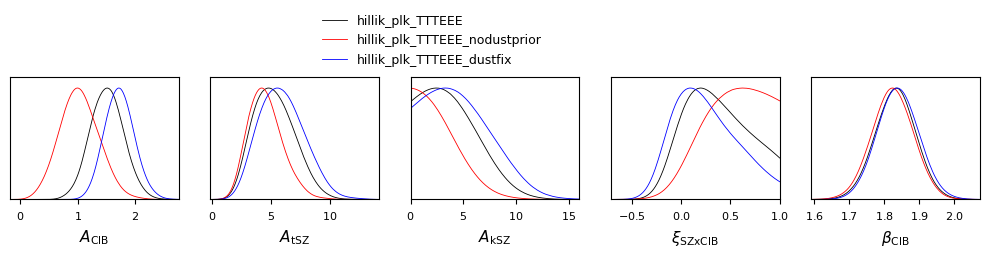

In [2]:
runnames = ['hillik_plk_TTTEEE','hillik_plk_TTTEEE_nodustprior','hillik_plk_TTTEEE_dustfix']
chains = [MCtools.mergeMC( f"{DBdir}/{run}/mcmc", burnin=-20000) for run in runnames[:1]]
for r in runnames[1:]: chains.append( MCtools.mergeMC( f"{DBdir}/dust/{r}/mcmc", burnin=0.7))
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames, ranges={'Aksz':[0,16],'xi':[-1,1]}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.plots_1d(samples, listpar, nx=5, legend_labels=runnames)

<Figure size 1000x1000 with 0 Axes>

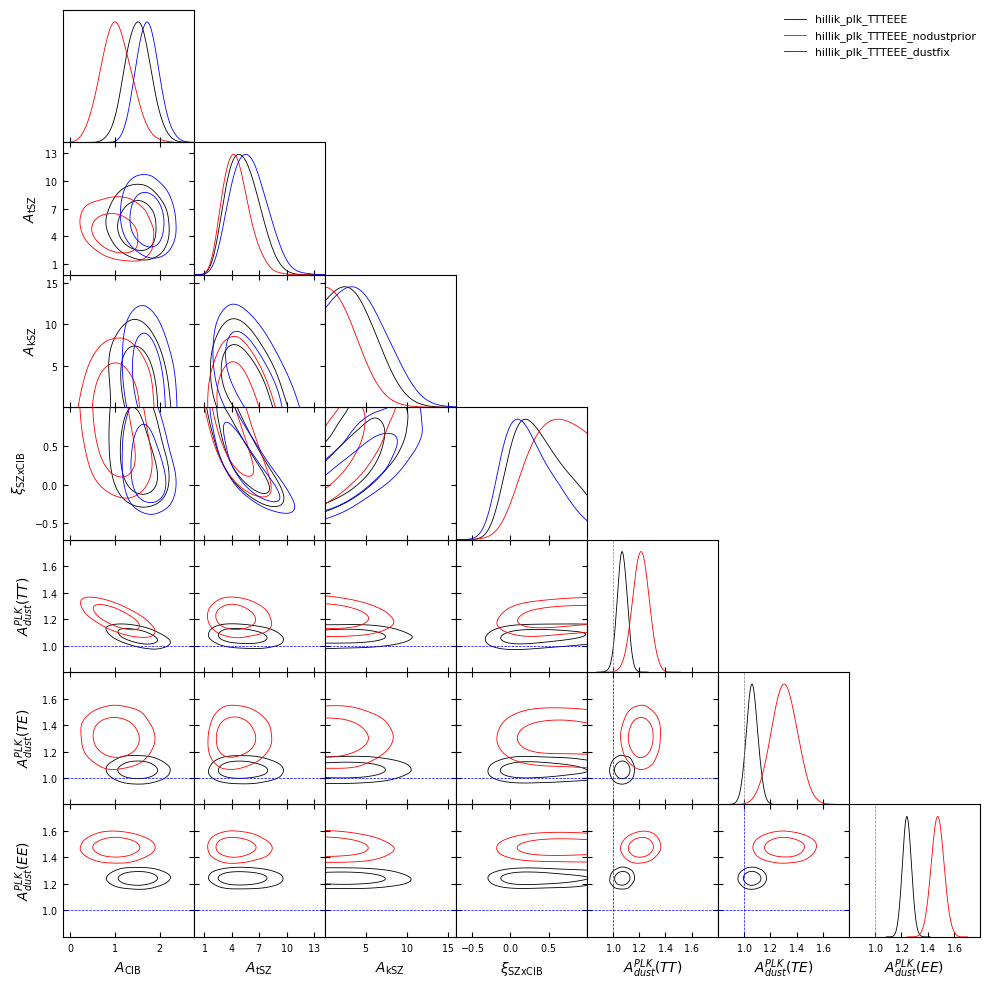

In [3]:
listpar = ['Acib','Atsz','Aksz','xi','PLK_AdustTT','PLK_AdustTE','PLK_AdustEE']
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain.keys()], names=[p for p in listpar if p in chain.keys()], labels=parnames, ranges={'Aksz':[0,16],'xi':[-1,1]}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, legend_labels=runnames, legend_loc='upper right', 
                markers={f'PLK_Adust{t}':1. for t in ['TT','TE','EE']}, marker_args={'color': 'b'}, 
                param_limits={f'PLK_Adust{t}':(0.8,1.8) for t in ['TT','TE','EE']})

(6, 1)

<Figure size 1500x1500 with 0 Axes>

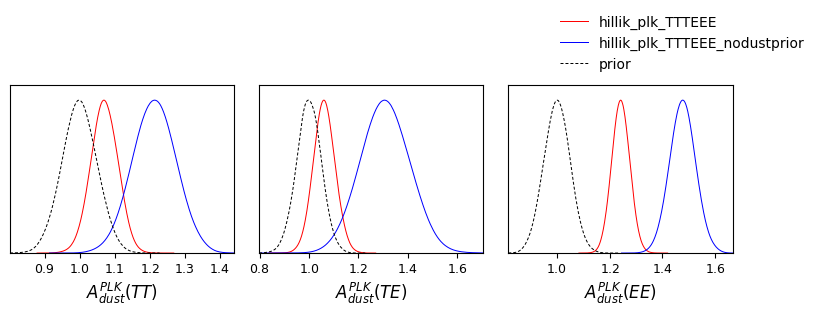

In [4]:
listpar = ['PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE']
parnames = ['A_{dust}^{PLK}(%s)' % p[-2:] for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames) for chain in chains if 'PLK_AdustTT' in chain]
prior   = [MCSamples( samples=[np.random.randn(10000)*0.05+1. for p in listpar], names=listpar, labels=listpar)]
g = plots.getSinglePlotter(width_inch=15,ratio=1)
g.plots_1d(samples+prior, listpar, nx=6, legend_labels=[runnames[i] for i in range(len(runnames)) if 'PLK_AdustTT' in chains[i]]+['prior'], colors=['r','b','g','y'][:len(samples)]+['k'], ls=['-']*len(samples)+['--'])

(6, 1)

<Figure size 1200x1200 with 0 Axes>

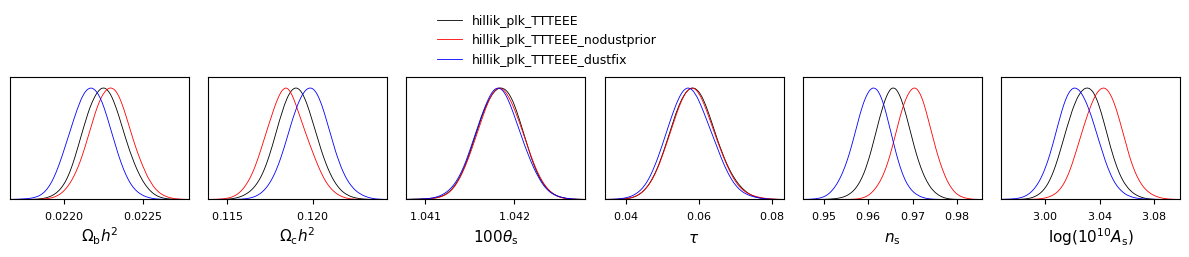

In [5]:
#Cosmo
listpar = ['omegabh2','omegach2','theta_s_100','tau','ns','logA']
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames) for chain in chains]
g = plots.getSinglePlotter(width_inch=12,ratio=1)
g.plots_1d(samples, listpar, nx=6, legend_labels=runnames)

### Dust Power Spectrum Index

hillik_plk_TTTEEE_nodustprior: 87743  79201  82256  88236 
hillik_plk_TTTEEE_alphaprior: 91315  88001  91095  92442 
hillik_plk_TTTEEE_alphaPR3: 77798  75681  79079  76960 
hillik_plk_TTTEEE_alphafree: 116524  123340  122001  122653 


(5, 1)

<Figure size 1500x1500 with 0 Axes>

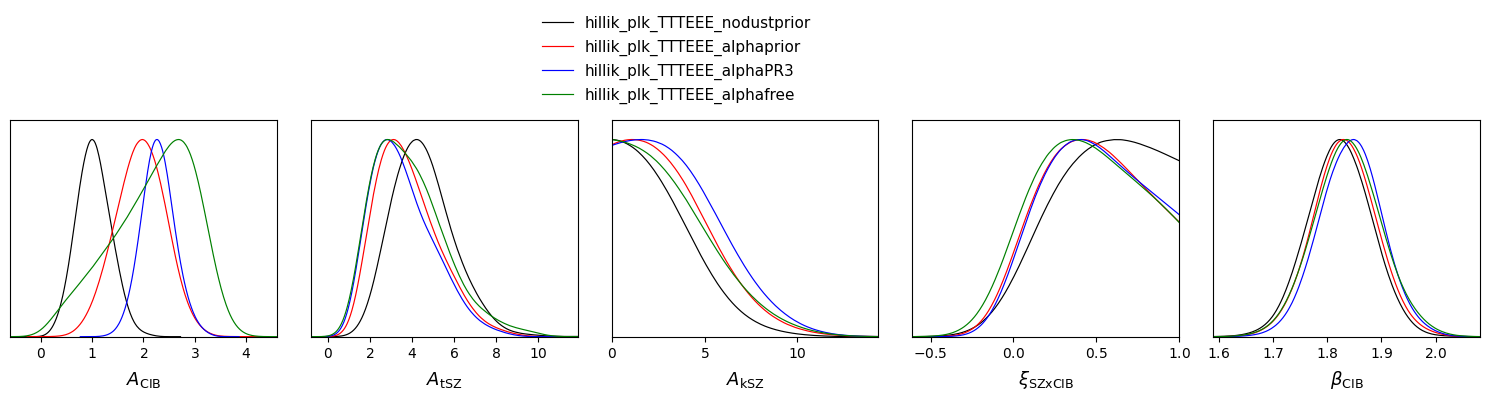

In [6]:
runnames = ['hillik_plk_TTTEEE_nodustprior','hillik_plk_TTTEEE_alphaprior','hillik_plk_TTTEEE_alphaPR3','hillik_plk_TTTEEE_alphafree']
chains = [MCtools.mergeMC( f"{DBdir}/dust/{run}/mcmc", burnin=-20000) for run in runnames]
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames, ranges={'Aksz':[0,16],'xi':[-1,1]}) for chain in chains]
g = plots.getSinglePlotter(width_inch=15, ratio=1)
g.plots_1d(samples, listpar, nx=5, legend_labels=runnames)

<Figure size 1000x1000 with 0 Axes>

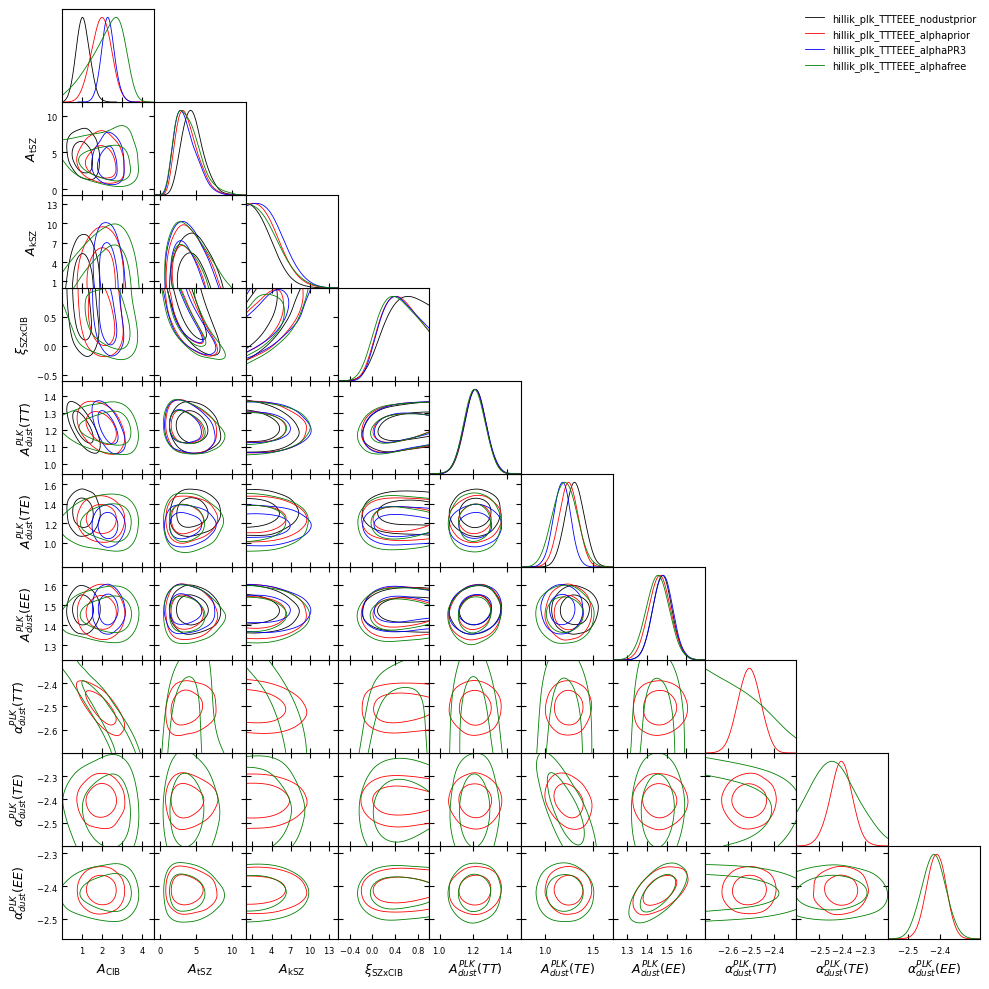

In [7]:
listpar = ['Acib','Atsz','Aksz','xi','PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE','PLK_alphaTT','PLK_alphaTE','PLK_alphaEE']
support = {'Acib':[0,5],'Aksz':[0,16],'xi':[-1,1],'PLK_alphaTT':[-2.7,-2.3],'PLK_alphaTE':[-2.6,-2.2],'PLK_alphaEE':[-2.6,-2.2]}
MCtools.parname.update({p:r'\alpha_{dust}^{PLK}(%s)' % p[-2:] for p in ['PLK_alphaTT','PLK_alphaTE','PLK_alphaEE']})
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain], names=[p for p in listpar if p in chain], labels=[MCtools.parname.get(p,p).replace('$','') for p in listpar if p in chain], ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, legend_labels=runnames, legend_loc='upper right')

(6, 1)

<Figure size 1200x1200 with 0 Axes>

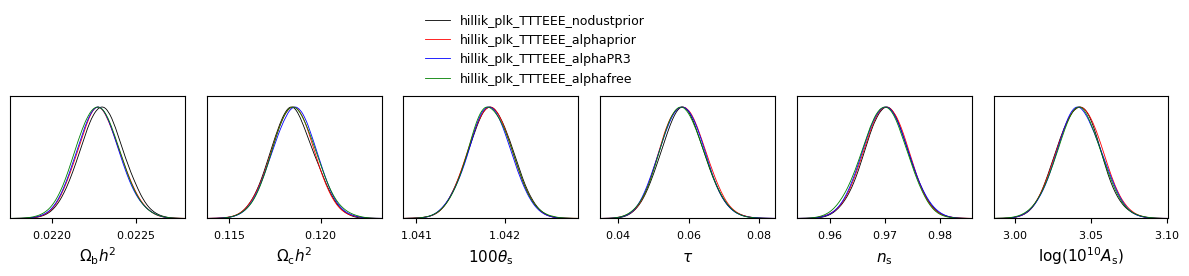

In [8]:
#cosmo
listpar = ['omegabh2','omegach2','theta_s_100','tau','ns','logA']
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames) for chain in chains]
g = plots.getSinglePlotter(width_inch=12,ratio=1)
g.plots_1d(samples, listpar, nx=6, legend_labels=runnames)

hillik_plk_TTTEEE_nodustprior: 87743  79201  82256  88236 
hillik_plk_TTTEEE_alphafree: 116524  123340  122001  122653 
hillik_plk_TTTEEE_alphaTT: 145001  152761  149729  149059 


<Figure size 1000x1000 with 0 Axes>

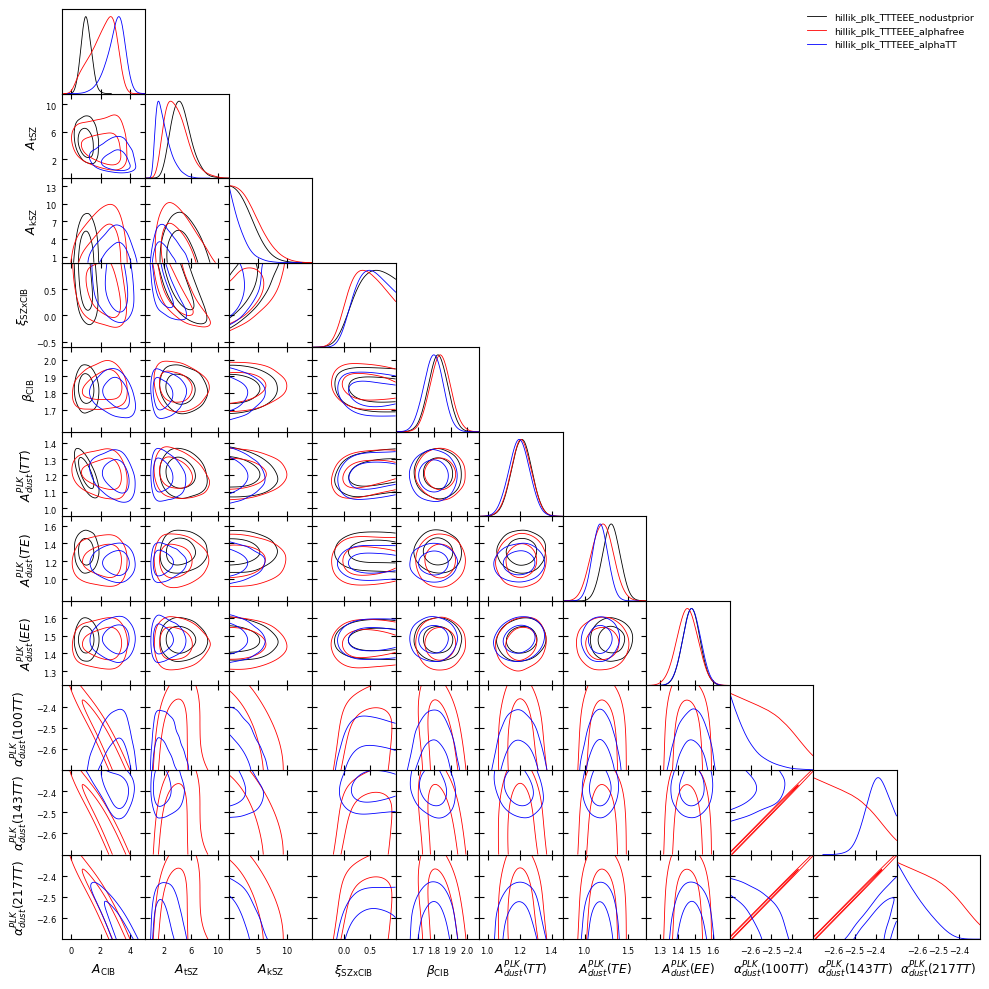

In [9]:
runnames = ['hillik_plk_TTTEEE_nodustprior','hillik_plk_TTTEEE_alphafree','hillik_plk_TTTEEE_alphaTT']
chains = [ MCtools.mergeMC( f"{DBdir}/dust/{run}/mcmc", burnin=0.7) for run in runnames]
for p in ['PLK_alpha_dust100TT','PLK_alpha_dust143TT','PLK_alpha_dust217TT']: chains[1][p] = chains[1]['PLK_alphaTT']
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib','PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE','PLK_alpha_dust100TT','PLK_alpha_dust143TT','PLK_alpha_dust217TT']
support = {'Aksz':[0,16],'xi':[-1,1],'PLK_alpha_dust100TT':[-2.7,-2.3],'PLK_alpha_dust143TT':[-2.7,-2.3],'PLK_alpha_dust217TT':[-2.7,-2.3]}
MCtools.parname.update({p:r'$\alpha_{dust}^{PLK}(%s)$' % p[-5:] for p in ['PLK_alpha_dust100TT','PLK_alpha_dust143TT','PLK_alpha_dust217TT']})
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain], names=[p for p in listpar if p in chain], labels=[MCtools.parname.get(p,p).replace('$','') for p in listpar if p in chain], ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, legend_labels=runnames, legend_loc='upper right')

## Correlations

hillik_plk_TTTEEE: 59236  47521  58000  59305 
hillik_plk_TTTEEE_nodustprior: 87743  79201  82256  88236 
hillik_plk_TTTEEE_alphafree: 116524  123340  122001  122653 


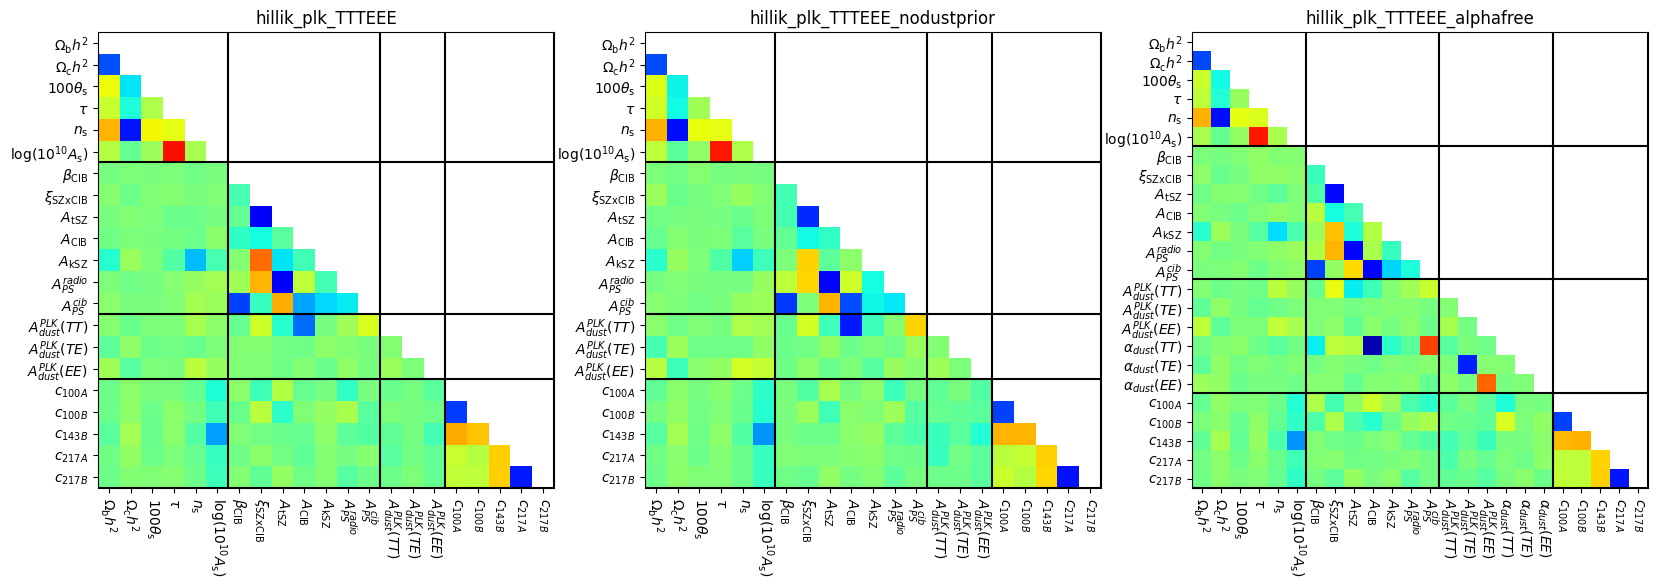

In [10]:
runnames = ['hillik_plk_TTTEEE','hillik_plk_TTTEEE_nodustprior','hillik_plk_TTTEEE_alphafree']
chains = [MCtools.mergeMC( f"{DBdir}/{runnames[0]}/mcmc", burnin=-20000)]
for run in runnames[1:]: chains.append(MCtools.mergeMC( f"{DBdir}/dust/{run}/mcmc", burnin=-20000))
pars_cosmo = ['omegabh2','omegach2','theta_s_100','tau','ns','logA']
pars_exgal = ['beta_cib','xi','Atsz','Acib','Aksz','PLK_radio_ps', 'PLK_cib_ps']
pars_galfg = ['PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE']
pars_cal   = ['PLK_cal_100A', 'PLK_cal_100B', 'PLK_cal_143B', 'PLK_cal_217A', 'PLK_cal_217B']
MCtools.parname.update({p:r'$\alpha_{dust}(%s)$' % p[-2:] for p in ['PLK_alphaTT','PLK_alphaTE','PLK_alphaEE']})
MCtools.parname.update({f'PLK_{p}_ps':r'$A^{%s}_{PS}$' % p for p in ['radio','cib']})
MCtools.parname.update({f'PLK_cal_{d}':r'$c_{%s}$' % d for d in ['100A','100B','143B','217A','217B']})
plt.figure(figsize=(20,7))
for s,chain in enumerate(chains):
    plt.subplot( 1,len(chains),s+1)
    if s>1: pars_galfg = pars_galfg+['PLK_alphaTT', 'PLK_alphaTE', 'PLK_alphaEE']
    corr = MCtools.MCcorrelation( chain, pars_cosmo+pars_exgal+pars_galfg+pars_cal, plot=True)
    icol = [len(p) for p in [pars_cosmo,pars_exgal,pars_galfg,pars_cal]]
    for p in np.cumsum(icol): plt.axvline( p-0.5, color='k')
    for p in np.cumsum(icol): plt.axhline( p-0.5, color='k')
    plt.title(runnames[s])